# Pandas para finanças - Saia do zero em uma aula

<br>

* O que é o Pandas?
* Material PDF na descrição 
* Como baixar o Python
* Básico do Python no card

# Tópico 1 - O que são DataFrames e Series?

In [1]:
import pandas as pd
import yfinance as yf

In [3]:
#criar um dataframe

dicionario = {"empresa": ['Weg', 'Petrobras', 'Vale'],
             "cotacoes": [20, 30, 50.43]}

df = pd.DataFrame(dicionario)

display(df)

,empresa,cotacoes
0,Weg,20.00
1,Petrobras,30.00
2,Vale,50.43


In [4]:
dados_empresas = yf.download("WEGE3.SA", start = "2018-01-01", end = "2022-12-31")

display(dados_empresas)

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-02,9.365384,9.680769,9.365384,9.623076,8.969450,4812860
2018-01-03,9.576923,9.596153,9.457692,9.476923,8.833221,4652960
2018-01-04,9.530769,9.584615,9.384615,9.384615,8.747182,3317600
2018-01-05,9.469230,9.480769,9.342307,9.423076,8.783031,2552680
2018-01-08,9.426923,9.557692,9.253846,9.500000,8.854732,3346200
...,...,...,...,...,...,...
2022-12-23,39.160000,39.380001,38.070000,38.500000,38.500000,9476400
2022-12-26,38.330002,38.740002,37.910000,38.189999,38.189999,2339100
2022-12-27,38.500000,38.520000,37.779999,38.009998,38.009998,4735700


# Tópico 2 - Como selecionar colunas no Pandas 

In [7]:
dados_ajustados = dados_empresas['Adj Close']

dados_ajustados

duas_colunas = dados_empresas[['Adj Close', 'Volume']]

duas_colunas

,Adj Close,Volume,Open
Date,,,
2018-01-02,8.969450,4812860,9.365384
2018-01-03,8.833221,4652960,9.576923
2018-01-04,8.747182,3317600,9.530769
2018-01-05,8.783031,2552680,9.469230
2018-01-08,8.854732,3346200,9.426923
...,...,...,...
2022-12-23,38.500000,9476400,39.160000
2022-12-26,38.189999,2339100,38.330002
2022-12-27,38.009998,4735700,38.500000


# Tópico 3 - Loc e Iloc - Como pegar dados em um determinado tempo

* Loc é um operador que você vai utilizar junto com os nomes
* Iloc é um operado que você vai utilizar com números (matriz)

In [10]:
dados_empresas

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-02,9.365384,9.680769,9.365384,9.623076,8.969450,4812860
2018-01-03,9.576923,9.596153,9.457692,9.476923,8.833221,4652960
2018-01-04,9.530769,9.584615,9.384615,9.384615,8.747182,3317600
2018-01-05,9.469230,9.480769,9.342307,9.423076,8.783031,2552680
2018-01-08,9.426923,9.557692,9.253846,9.500000,8.854732,3346200
...,...,...,...,...,...,...
2022-12-23,39.160000,39.380001,38.070000,38.500000,38.500000,9476400
2022-12-26,38.330002,38.740002,37.910000,38.189999,38.189999,2339100
2022-12-27,38.500000,38.520000,37.779999,38.009998,38.009998,4735700


In [14]:
dados_empresas.loc["2018-01-03", "Adj Close"]

dados_empresas.iloc[1, 4]

dados_empresas.iloc[-1, :]

dados_empresas.iloc[:, 0]

dados_empresas.loc["2018-01-03": "2018-01-27", "Adj Close"]

Date
2018-01-03    8.833221
2018-01-04    8.747182
2018-01-05    8.783031
2018-01-08    8.854732
2018-01-09    8.998126
2018-01-10    8.926433
2018-01-11    9.098503
2018-01-12    9.166617
2018-01-15    9.227563
2018-01-16    9.338694
2018-01-17    9.284921
2018-01-18    9.155863
2018-01-19    9.281338
2018-01-22    9.177372
2018-01-23    8.912092
2018-01-24    8.926433
2018-01-25    8.926433
2018-01-26    8.965859
Name: Adj Close, dtype: float64

# Tópico 4 - Como calcular rentabilidade com o Pandas

In [20]:
cotacoes_ajustadas = dados_empresas['Adj Close']

retornos_diarios = cotacoes_ajustadas.pct_change().dropna()

retorno_5_dias = cotacoes_ajustadas.pct_change(periods = 5).dropna()

display(retorno_5_dias)
display(retornos_diarios)

Date
2018-01-09    0.003197
2018-01-10    0.010552
2018-01-11    0.040164
2018-01-12    0.043674
2018-01-15    0.042105
                ...   
2022-12-23    0.029532
2022-12-26    0.001836
2022-12-27   -0.010929
2022-12-28    0.007812
2022-12-29   -0.011043
Name: Adj Close, Length: 1234, dtype: float64

Date
2018-01-03   -0.015188
2018-01-04   -0.009740
2018-01-05    0.004098
2018-01-08    0.008164
2018-01-09    0.016194
                ...   
2022-12-23   -0.011299
2022-12-26   -0.008052
2022-12-27   -0.004713
2022-12-28    0.018153
2022-12-29   -0.004910
Name: Adj Close, Length: 1238, dtype: float64

# Tópico 5 - Como readequar uma série de tempo 

In [24]:
cotacoes_ajustadas

cotacoes_mensais = cotacoes_ajustadas.resample("M").last()

r1 = cotacoes_mensais.pct_change().dropna()

r6 = cotacoes_mensais.pct_change(periods = 6).dropna()

display(r6)

Date
2018-07-31    0.028270
2018-08-31    0.076440
2018-09-30    0.145670
2018-10-31    0.021387
2018-11-30    0.046487
2018-12-31    0.092233
2019-01-31    0.022922
2019-02-28   -0.028574
2019-03-31   -0.079557
2019-04-30    0.042472
2019-05-31    0.079640
2019-06-30    0.226234
2019-07-31    0.280546
2019-08-31    0.231780
2019-09-30    0.356256
2019-10-31    0.382787
2019-11-30    0.608885
2019-12-31    0.636735
2020-01-31    0.659140
2020-02-29    0.929666
2020-03-31    0.393027
2020-04-30    0.574815
2020-05-31    0.382580
2020-06-30    0.467613
2020-07-31    0.720922
2020-08-31    0.502971
2020-09-30    0.963386
2020-10-31    0.904691
2020-11-30    0.764430
2020-12-31    0.500957
2021-01-31    0.245396
2021-02-28    0.209091
2021-03-31    0.141066
2021-04-30   -0.071566
2021-05-31   -0.066552
2021-06-30   -0.105415
2021-07-31   -0.142876
2021-08-31   -0.079629
2021-09-30    0.068955
2021-10-31    0.062725
2021-11-30   -0.050968
2021-12-31   -0.015322
2022-01-31   -0.094120
2022-0

# Tópico 6 - Como ler arquivos com o Pandas

In [25]:
dados_pl = pd.read_excel(r'C:\Users\lsiqu\videos_youtube\dados_yt\dados_pl.xlsx')

display(dados_pl)

,codigo,empresa,preco,quant_acoes,lucro_liquido
0,AALR3,ALLIAR,14.97,118292816,-128836000
1,ABCB4,ABC BRASIL,15.87,226090118,763129000
2,ABEV3,AMBEV S/A,15.42,15741455000,13554865000
3,AERI3,AERIS,6.55,766213456,-35173000
4,AESB3,AES BRASIL,11.07,399106517,102568000
...,...,...,...,...,...
398,WHRL4,WHIRLPOOL,8.00,1502786000,543169000
399,WIZS3,WIZ S.A.,7.96,159907282,218528000
400,WLMM4,WLM IND COM,39.84,36414670,113400000
401,YDUQ3,YDUQS PART,20.56,309089000,-45505000


# Tópico 7 - Operações aritméticas com o Pandas

In [26]:
dados_pl['lpa'] = dados_pl['lucro_liquido']/dados_pl['quant_acoes']

dados_pl

,codigo,empresa,preco,quant_acoes,lucro_liquido,lpa
0,AALR3,ALLIAR,14.97,118292816,-128836000,-1.089128
1,ABCB4,ABC BRASIL,15.87,226090118,763129000,3.375331
2,ABEV3,AMBEV S/A,15.42,15741455000,13554865000,0.861094
3,AERI3,AERIS,6.55,766213456,-35173000,-0.045905
4,AESB3,AES BRASIL,11.07,399106517,102568000,0.256994
...,...,...,...,...,...,...
398,WHRL4,WHIRLPOOL,8.00,1502786000,543169000,0.361441
399,WIZS3,WIZ S.A.,7.96,159907282,218528000,1.366592
400,WLMM4,WLM IND COM,39.84,36414670,113400000,3.114130
401,YDUQ3,YDUQS PART,20.56,309089000,-45505000,-0.147223


In [27]:
dados_pl['p_l'] = dados_pl['preco']/dados_pl['lpa']

dados_pl

,codigo,empresa,preco,quant_acoes,lucro_liquido,lpa,p_l
0,AALR3,ALLIAR,14.97,118292816,-128836000,-1.089128,-13.744943
1,ABCB4,ABC BRASIL,15.87,226090118,763129000,3.375331,4.701761
2,ABEV3,AMBEV S/A,15.42,15741455000,13554865000,0.861094,17.907462
3,AERI3,AERIS,6.55,766213456,-35173000,-0.045905,-142.686098
4,AESB3,AES BRASIL,11.07,399106517,102568000,0.256994,43.074927
...,...,...,...,...,...,...,...
398,WHRL4,WHIRLPOOL,8.00,1502786000,543169000,0.361441,22.133605
399,WIZS3,WIZ S.A.,7.96,159907282,218528000,1.366592,5.824709
400,WLMM4,WLM IND COM,39.84,36414670,113400000,3.114130,12.793302
401,YDUQ3,YDUQS PART,20.56,309089000,-45505000,-0.147223,-139.652123


# Tópico 8 - Como filtrar dados em tabelas

In [32]:
empresas_lucrativas_e_com_pl_abaixo_10 = dados_pl[(dados_pl['p_l'] > 0) &
                                                 (dados_pl['p_l'] < 10)]

display(empresas_lucrativas_e_com_pl_abaixo_10)

,codigo,empresa,preco,quant_acoes,lucro_liquido,lpa,p_l
1,ABCB4,ABC BRASIL,15.87,226090118,763129000,3.375331,4.701761
5,AFLT3,AFLUENTE T,8.87,63085000,119734000,1.897979,4.673392
6,AGRO3,BRASILAGRO,28.79,102377008,454231000,4.436846,6.488844
16,ALUP3,ALUPAR,8.09,879111269,1713489000,1.949115,4.150602
17,ALUP4,ALUPAR,8.04,879111269,1713489000,1.949115,4.124949
...,...,...,...,...,...,...,...
382,USIM3,USIMINAS,14.51,1253079108,5419779000,4.325169,3.354782
383,USIM5,USIMINAS,15.16,1253079108,5419779000,4.325169,3.505065
384,VALE3,VALE,77.96,5132458000,107423956000,20.930314,3.724741
393,VULC3,VULCABRAS,9.14,245756000,336850000,1.370668,6.668279


# Tópico 9 - Ordenando dados 

In [38]:
melhores_empresas = empresas_lucrativas_e_com_pl_abaixo_10.sort_values(by = "p_l")

melhores_empresas.head(10)

,codigo,empresa,preco,quant_acoes,lucro_liquido,lpa,p_l
238,MEGA3,OMEGAENERGIA,12.65,100,598231000,5.982310e+06,0.000002
340,SLED4,SARAIVA LIVR,6.21,1811720,152670000,8.426799e+01,0.073693
276,PDGR3,PDG REALT,1.36,56133000,623029000,1.109916e+01,0.122532
339,SLED3,SARAIVA LIVR,13.66,1811720,152670000,8.426799e+01,0.162102
200,INEP4,INEPAR,1.50,165301000,1105465000,6.687588e+00,0.224296
199,INEP3,INEPAR,1.52,165301000,1105465000,6.687588e+00,0.227287
193,HOOT4,HOTEIS OTHON,2.80,18372000,118458000,6.447747e+00,0.434260
180,GOAU3,GERDAU MET,10.63,1087243204,13820166000,1.271120e+01,0.836270
352,SYNE3,SYN PROP TEC,7.20,152644000,1305462000,8.552331e+00,0.841876
181,GOAU4,GERDAU MET,11.38,1087243204,13820166000,1.271120e+01,0.895273


# Tópico 10 - Rankings no Pandas

In [39]:
melhores_empresas['Ranking_pl'] = melhores_empresas['p_l'].rank()

melhores_empresas

,codigo,empresa,preco,quant_acoes,lucro_liquido,lpa,p_l,Ranking_pl
238,MEGA3,OMEGAENERGIA,12.65,100,598231000,5.982310e+06,0.000002,1.0
340,SLED4,SARAIVA LIVR,6.21,1811720,152670000,8.426799e+01,0.073693,2.0
276,PDGR3,PDG REALT,1.36,56133000,623029000,1.109916e+01,0.122532,3.0
339,SLED3,SARAIVA LIVR,13.66,1811720,152670000,8.426799e+01,0.162102,4.0
200,INEP4,INEPAR,1.50,165301000,1105465000,6.687588e+00,0.224296,5.0
...,...,...,...,...,...,...,...,...
375,TTEN3,3TENTOS,9.73,494118000,514212000,1.040666e+00,9.349778,158.0
149,ENGI3,ENERGISA,13.67,1814561910,2627742000,1.448141e+00,9.439687,159.0
72,BRSR5,BANRISUL,16.80,408974000,711632000,1.740042e+00,9.654939,160.0
124,CXSE3,CAIXA SEGURI,8.36,3000000000,2549801000,8.499337e-01,9.836062,161.0


# Tópico 11 - Criando modelos de média móvel com o Pandas

In [46]:
media_movel = pd.DataFrame(index = cotacoes_ajustadas.index)

media_movel['cotacoes_weg'] = cotacoes_ajustadas.values

media_movel['media_movel_devagar'] = media_movel['cotacoes_weg'].rolling(200).mean()

media_movel['media_movel_rapida'] = media_movel['cotacoes_weg'].rolling(50).mean()

media_movel = media_movel.dropna()

media_movel

,cotacoes_weg,media_movel_devagar,media_movel_rapida
Date,,,
2018-10-18,8.706826,8.396709,8.816716
2018-10-19,8.796681,8.395845,8.821508
2018-10-22,8.820330,8.395781,8.827434
2018-10-23,9.080448,8.397447,8.845453
2018-10-24,9.151389,8.399289,8.862059
...,...,...,...
2022-12-23,38.500000,31.158483,37.845585
2022-12-26,38.189999,31.192532,37.940956
2022-12-27,38.009998,31.227314,38.044910


<AxesSubplot:xlabel='Date'>

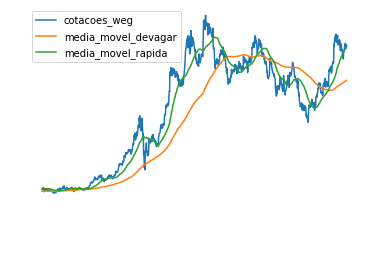

In [50]:
media_movel.plot()